#Telecom Customer Churn Analysis
###Python Data Analysis Project
**Tools:** Python, Pandas, Matplotlib  
**Dataset:** Telco Customer Churn  
**Objective:** Analyze customer behavior and identify factors associated with customer churn.

##Project Objective
To analyze telecom customer data,identify reasons/patterns related to customer churn, and to generate business insights that can support customer retention strategies.

In [1]:
import pandas as pd
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df['TotalCharges'].dtype

dtype('O')

In [11]:
df[df['TotalCharges'].str.strip()== '']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [21]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'],
errors='coerce')

In [22]:
df['TotalCharges'].dtype

dtype('float64')

In [23]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [24]:
df['TotalCharges']=df['TotalCharges'].fillna(0)

In [25]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df['customerID'].duplicated().sum()

np.int64(0)

In [28]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [29]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [30]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


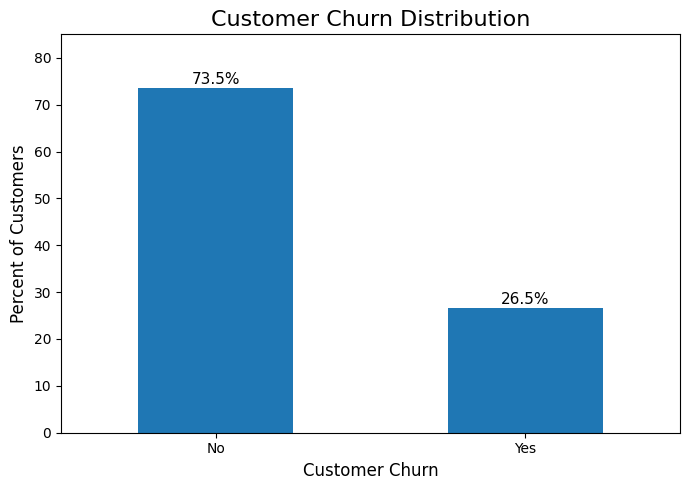

In [32]:
import matplotlib.pyplot as plt
churn_percent=df['Churn'].value_counts(normalize=True)*100
ax=churn_percent.plot(kind='bar',figsize=(7,5))
plt.title('Customer Churn Distribution',fontsize=16)
plt.xlabel('Customer Churn',fontsize=12)
plt.ylabel('Percent of Customers',fontsize=12)
for i,value in enumerate(churn_percent):ax.text(i,value+1,f'{value:.1f}%',ha='center',fontsize=11)
plt.xticks(rotation=0)
plt.ylim(0,85)
plt.tight_layout()
plt.show()

In [36]:
churn_by_contract=pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100
churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


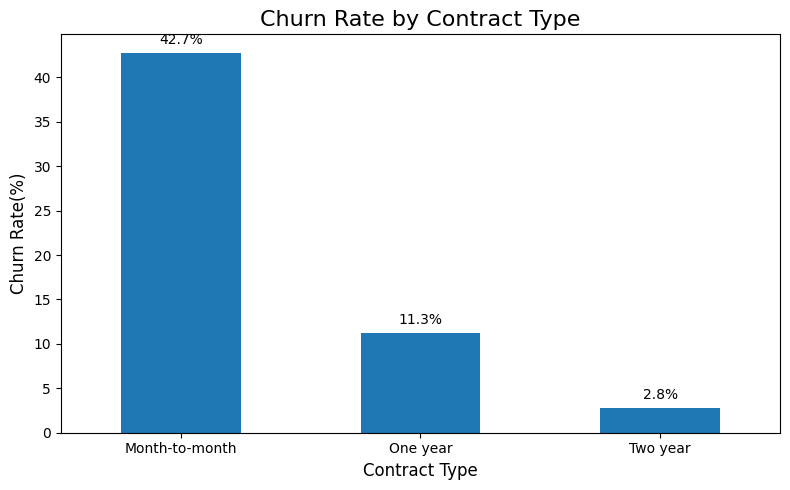

In [37]:
ax=churn_by_contract['Yes'].sort_values(ascending=False).plot(kind='bar',figsize=(8,5))
plt.title('Churn Rate by Contract Type',fontsize=16)
plt.xlabel('Contract Type',fontsize=12)
plt.ylabel('Churn Rate(%)',fontsize=12)
plt.xticks(rotation=0)
for i,value in enumerate(churn_by_contract['Yes'].sort_values(ascending=False)):ax.text(i, value+1,f'{value:.1f}%',ha='center')
plt.tight_layout()
plt.show()



In [38]:
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


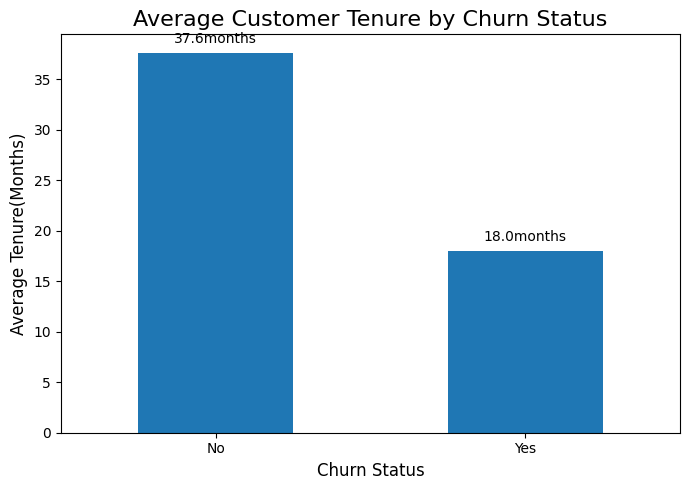

In [39]:
avg_tenure=df.groupby('Churn')['tenure'].mean()
ax=avg_tenure.plot(kind='bar',figsize=(7,5))
plt.title('Average Customer Tenure by Churn Status',fontsize=16)
plt.xlabel('Churn Status',fontsize=12)
plt.ylabel('Average Tenure(Months)',fontsize=12)
plt.xticks(rotation=0)
for i,value in enumerate(avg_tenure):ax.text(i,value+1,f'{value:.1f}months',ha='center')
plt.tight_layout()
plt.show()

In [40]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


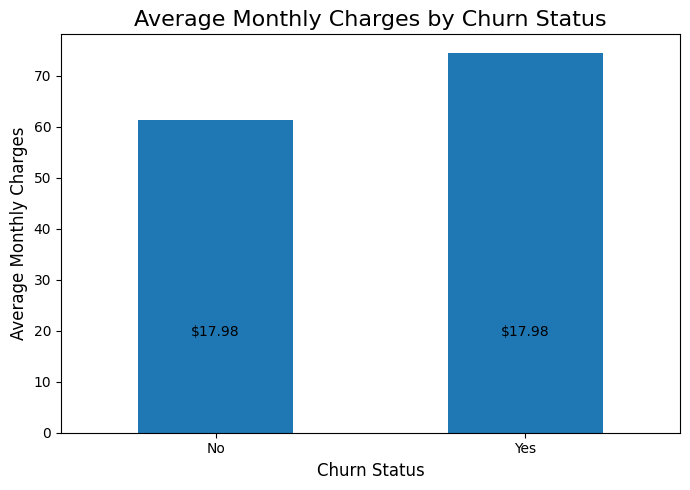

In [43]:
avg_charges=df.groupby('Churn')['MonthlyCharges'].mean()
ax=avg_charges.plot(kind='bar',figsize=(7,5))
plt.title('Average Monthly Charges by Churn Status',fontsize=16)
plt.xlabel('Churn Status',fontsize=12)
plt.ylabel('Average Monthly Charges',fontsize=12)
plt.xticks(rotation=0)
for i,values in enumerate(avg_charges):ax.text(i,value+1,f'${value:.2f}',ha='center')
plt.tight_layout()
plt.show()


In [44]:
churn_by_partner=pd.crosstab(df['Partner'],df['Churn'],normalize='index')*100
churn_by_partner

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


In [45]:
churn_by_dependents=pd.crosstab(df['Dependents'],df['Churn'],normalize='index')*100
churn_by_dependents

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


In [46]:
churn_by_internet=pd.crosstab(df['InternetService'],df['Churn'],normalize='index')*100
churn_by_internet

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [47]:
churn_by_payment=pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index')*100
churn_by_payment

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


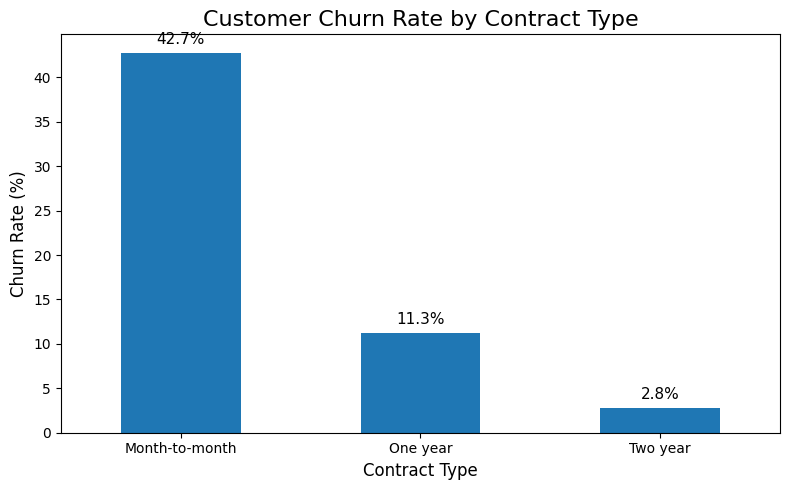

In [48]:
contract_churn = churn_by_contract['Yes'].sort_values(ascending=False)

ax = contract_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Customer Churn Rate by Contract Type', fontsize=16)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=0)

for i, value in enumerate(contract_churn):
    ax.text(i, value + 1, f'{value:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

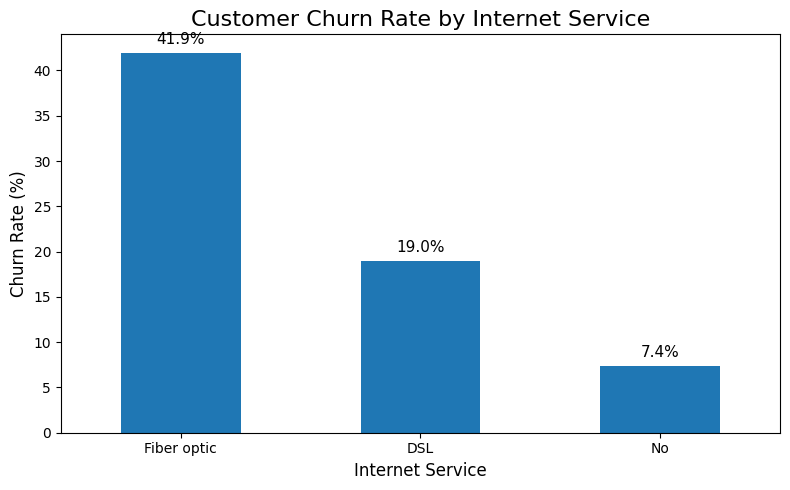

In [49]:
internet_churn = churn_by_internet['Yes'].sort_values(ascending=False)

ax = internet_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Customer Churn Rate by Internet Service', fontsize=16)
plt.xlabel('Internet Service', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=0)

for i, value in enumerate(internet_churn):
    ax.text(i, value + 1, f'{value:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()


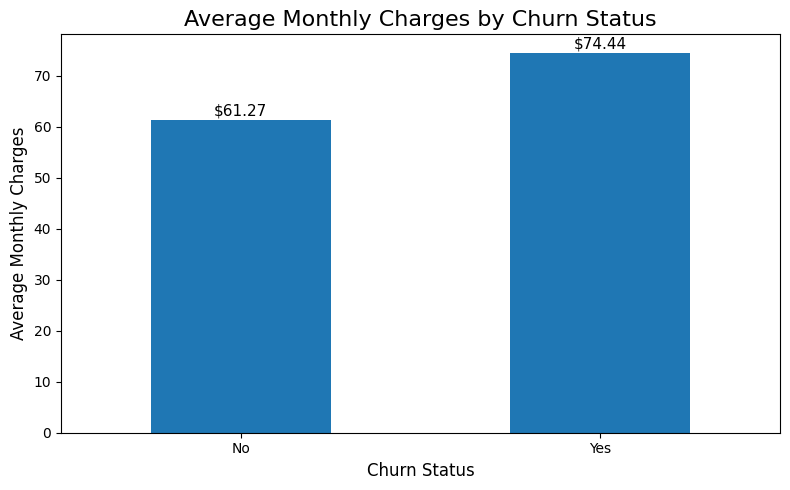

In [50]:
charges_by_churn = df.groupby('Churn')['MonthlyCharges'].mean()

ax = charges_by_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Monthly Charges by Churn Status', fontsize=16)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Average Monthly Charges', fontsize=12)
plt.xticks(rotation=0)

for i, value in enumerate(charges_by_churn):
    ax.text(i, value + 1, f'${value:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

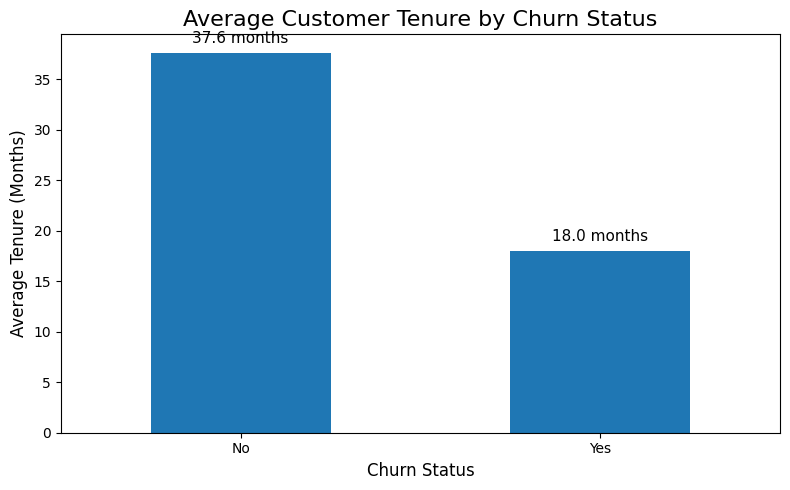

In [51]:
tenure_by_churn = df.groupby('Churn')['tenure'].mean()

ax = tenure_by_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Customer Tenure by Churn Status', fontsize=16)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Average Tenure (Months)', fontsize=12)
plt.xticks(rotation=0)

for i, value in enumerate(tenure_by_churn):
    ax.text(i, value + 1, f'{value:.1f} months', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

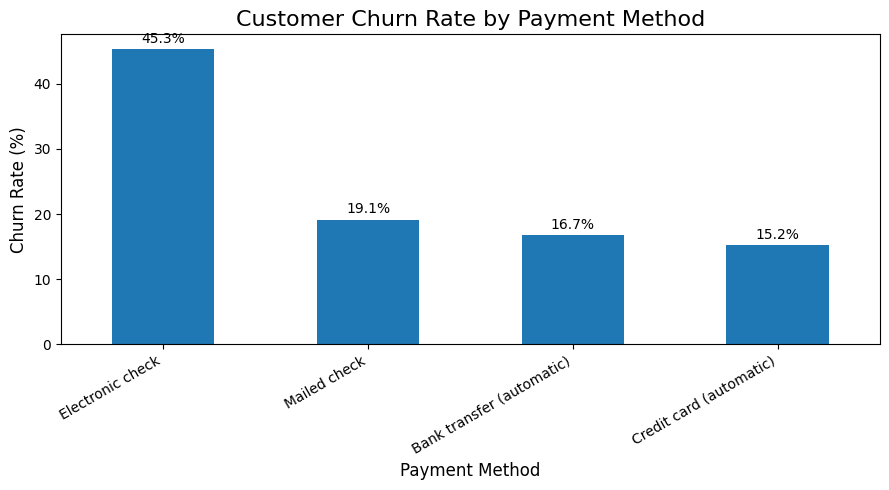

In [52]:
payment_churn = churn_by_payment['Yes'].sort_values(ascending=False)

ax = payment_churn.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Customer Churn Rate by Payment Method', fontsize=16)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=30, ha='right')

for i, value in enumerate(payment_churn):
    ax.text(i, value + 1, f'{value:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Key Findings

1. The overall customer churn rate is approximately 26.5%.

2. Month-to-month contract customers have the highest churn rate, while customers on two-year contracts have the lowest churn.

3. Customers who churned had a lower average tenure (17.9 months) comparatively customers who stayed (37.5 months).

4. Churned customers had higher average monthly charges ($74.44) than retained customers ($61.27).

5. Fiber optic customers had the highest churn rate among the internet service categories.

6. Electronic check customers had the highest churn rate among the payment methods.

7. Customers without partners or dependents showed higher churn rates than customers with partners or dependents.

## Business Recommendations

Based on the analysis, the following actions could help reduce customer churn:

- Encourage month-to-month customers to move to longer-term contracts through targeted discounts or loyalty benefits.

- Develop an onboarding and engagement program for newer customers, since churn is considerably higher among customers with shorter tenure.

- Review pricing and perceived value for customers with higher monthly charges and identify opportunities for personalized offers.

- Investigate customer satisfaction and service quality among fiber optic customers to understand the reasons behind their higher churn rate.

- Evaluate the electronic check payment experience and encourage customers to use alternative payment methods where appropriate.

- Develop targeted retention campaigns for customer segments with consistently higher churn rates.


## Conclusion

This analysis identified several factors associated with customer churn in the telecom dataset.

Customers on month-to-month contracts, customers with shorter tenure, customers with higher monthly charges, fiber optic users, and electronic check users showed higher churn rates.

The findings suggest that the company should focus on improving early customer engagement, encouraging longer-term contracts, reviewing pricing and service experience, and developing targeted retention strategies for high-risk customer segments.

Overall, this project demonstrates how Python and data analysis can be used to transform customer data into actionable business insights and support data-driven retention strategies.

## Skills Demonstrated

- Python
- Pandas
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- GroupBy and Crosstab Analysis
- Business Insight Generation
- Customer Churn Analysis